<a href="https://colab.research.google.com/github/Nagalakshmirasapilli/smart-agriculture-dashboard/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.5 MB/s eta 0:00:00


In [7]:
import os
os.listdir()


['.config',
 '.ipynb_checkpoints',
 'Crop_recommendation.csv',
 'dashboard.py',
 'sample_data']

In [8]:
import pandas as pd

data = pd.read_csv("Crop_recommendation.csv")
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [9]:
data.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [10]:
data = data[['temperature','humidity','ph']]

In [11]:
data.head()

,temperature,humidity,ph
0,20.879744,82.002744,6.502985
1,21.770462,80.319644,7.038096
2,23.004459,82.320763,7.840207
3,26.491096,80.158363,6.980401
4,20.130175,81.604873,7.628473


In [12]:
def convert_to_binary(row):
    temp = 1 if row['temperature'] > 30 else 0
    humidity = 1 if row['humidity'] < 40 else 0
    ph = 1 if (row['ph'] < 6 or row['ph'] > 7.5) else 0
    return pd.Series([temp, humidity, ph])


In [13]:
binary_data = data.apply(convert_to_binary, axis=1)
binary_data.columns = ['q0','q1','q2']

In [14]:
binary_data.head()

,q0,q1,q2
0,0,0,0
1,0,0,0
2,0,0,1
3,0,0,0
4,0,0,1


In [15]:
binary_data.to_csv("binary_output.csv", index=False)

In [16]:
input_data = binary_data.iloc[0]
print(input_data)

q0    0
q1    0
q2    0
Name: 0, dtype: int64


In [17]:
!pip install qiskit

In [18]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(4,1)
if input_data[0] == 1:
    qc.x(0)

if input_data[1] == 1:
    qc.x(1)

if input_data[2] == 1:
    qc.x(2)

/tmp/ipykernel_763/1892563966.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if input_data[0] == 1:
/tmp/ipykernel_763/1892563966.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if input_data[1] == 1:
/tmp/ipykernel_763/1892563966.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if input_data[2] == 1:


In [19]:
qc.ccx(0,1,3)
qc.ccx(1,2,3)
qc.ccx(0,2,3)
qc.measure(3,0)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=67fc994b17abcf59ab43e814fd1c1b069ed55599c183086f5b2b56639c6f6b2e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


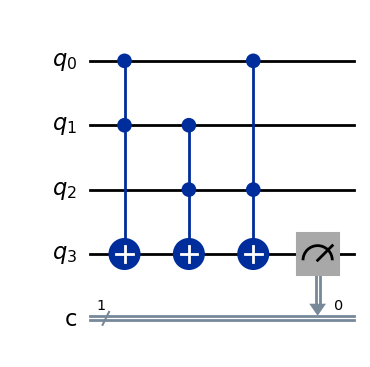

In [20]:
!pip install pylatexenc
qc.draw('mpl')

In [21]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.0 MB/s eta 0:00:00


In [22]:
from qiskit_aer import Aer
from qiskit import transpile

In [23]:
simulator = Aer.get_backend('aer_simulator')

qc = transpile(qc, simulator)

result = simulator.run(qc, shots=1000).result()
counts = result.get_counts()

print(counts)

{'0': 1000}


In [25]:
if '1' in counts:
    print("🚨 Irrigation_needed ")
else:
    print("✅ Normal Condition")

✅ Normal Condition


In [26]:
results = []

In [27]:
!pip install qiskit-aer

In [33]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

simulator = AerSimulator()
results = []

for i in range(len(binary_data)):

    input_data = binary_data.iloc[i]

    qc = QuantumCircuit(4,1)

    # Encode inputs
    if input_data[0] == 1: qc.x(0)
    if input_data[1] == 1: qc.x(1)
    if input_data[2] == 1: qc.x(2)

    # Decision logic
    qc.ccx(0,1,3)
    qc.ccx(1,2,3)
    qc.ccx(0,2,3)

    # Measure
    qc.measure(3,0)

    # Run circuit
    job = simulator.run(qc, shots=1)
    result = job.result()
    counts = result.get_counts()

    output = int(list(counts.keys())[0])

    # Convert to readable result
    if output == 1:
        decision = "Irrigation needed"
    else:
        decision = "Normal"

    results.append(decision)

/tmp/ipykernel_763/3429983187.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if input_data[0] == 1: qc.x(0)
/tmp/ipykernel_763/3429983187.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if input_data[1] == 1: qc.x(1)
/tmp/ipykernel_763/3429983187.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if input_data[2] == 1: qc.x(2)


In [34]:
binary_data['Decision'] = results

In [35]:
import pandas as pd

original_data = pd.read_csv('Crop_recommendation.csv')

In [36]:
print(len(original_data))
print(len(results))

2200
2200


In [37]:
original_data['Decision'] = results

In [38]:
original_data.to_csv('Final_Output.csv', index=False)

In [39]:
from google.colab import files
files.download('Final_Output.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [41]:
simulator = AerSimulator()

In [42]:
correct = 0
total = len(binary_data)

for i in range(total):

    input_data = binary_data.iloc[i]

    qc = QuantumCircuit(4,1)

    # Encode inputs
    if input_data[0] == 1: qc.x(0)
    if input_data[1] == 1: qc.x(1)
    if input_data[2] == 1: qc.x(2)

    # Decision logic
    qc.ccx(0,1,3)
    qc.ccx(1,2,3)
    qc.ccx(0,2,3)

    # Measure
    qc.measure(3,0)

    # Run without execute()
    job = simulator.run(qc, shots=1)
    result = job.result()
    counts = result.get_counts()

    # Get output
    output = int(list(counts.keys())[0])

    # Expected logic (classical)
    expected = 1 if (input_data[0] + input_data[1] + input_data[2] >= 2) else 0

    if output == expected:
        correct += 1

/tmp/ipykernel_763/1571092728.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if input_data[0] == 1: qc.x(0)
/tmp/ipykernel_763/1571092728.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if input_data[1] == 1: qc.x(1)
/tmp/ipykernel_763/1571092728.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if input_data[2] == 1: qc.x(2)
/tmp/ipykernel_763/1571092728.py:32: FutureWarning: Series.__getitem__ treating keys as positi

In [43]:
accuracy = (correct / total) * 100
print("Accuracy:", accuracy, "%")

Accuracy: 100.0 %
